# 02 — LP optimum vs every baseline

Quantifies how much L1 each existing method leaves on the table per
case, using SLP iter as the reference. Answers:

1. Is the LP/SLP route Pareto-best (strict feasibility AND smallest L1)?
2. Where do existing methods fall short, and by how much?
3. Does iteration matter? (`slp_iter` vs `lp_oneshot` L1 gap.)


In [1]:
from pathlib import Path
import pandas as pd

_HERE = Path.cwd()
OUTDIR = _HERE.parent / 'runners' / 'output' if (_HERE.name == 'analysis') else _HERE
if not (OUTDIR / 'comparison_synthetic.csv').exists():
    for parent in [_HERE, *_HERE.parents]:
        cand = parent / 'research' / 'strict_feasibility_2d' / 'runners' / 'output'
        if (cand / 'comparison_synthetic.csv').exists():
            OUTDIR = cand
            break
df_synth = pd.read_csv(OUTDIR / 'comparison_synthetic.csv')
df_b0039 = pd.read_csv(OUTDIR / 'comparison_b0039.csv') if (OUTDIR / 'comparison_b0039.csv').exists() else pd.DataFrame()
df = pd.concat([df_synth, df_b0039], ignore_index=True)
df.head(2)


,case_id,method,shape,init_n_neg_2tri,init_min_T,final_n_neg_2tri,final_min_T,feasible,L1_dev,L2_dev,Linf_dev,wall_s,error
0,01a_10x10_crossing,harmonic_only,10x10,16,-0.743932,0,0.147658,True,24.912511,5.756970,3.106366,0.005948,NaN
1,01a_10x10_crossing,m10,10x10,16,-0.743932,0,0.042751,True,8.396565,3.402374,2.269539,0.051979,NaN


In [2]:
# Gap table: percent L1 excess vs slp_iter on the same case (feasible-only).
df_feas = df[df['feasible']].copy()

ref = df_feas[df_feas['method'] == 'slp_iter'][['case_id', 'L1_dev']].rename(
    columns={'L1_dev': 'L1_slp'}
)
joined = df_feas.merge(ref, on='case_id', how='left')
joined['L1_gap_vs_slp'] = joined['L1_dev'] - joined['L1_slp']
joined['L1_gap_pct'] = 100 * joined['L1_gap_vs_slp'] / joined['L1_slp']

gap = joined.pivot_table(
    index='case_id', columns='method',
    values='L1_gap_pct', aggfunc='first',
).round(1)
gap


method,harmonic_only,lp_oneshot,m10,m14,m14_schwarz,slp_iter,slp_iter_m14_seed,slp_iter_wide_tr
case_id,,,,,,,,
01a_10x10_crossing,275.2,0.0,26.4,0.5,0.5,0.0,-0.0,0.0
01b_10x10_opposite,NaN,0.0,300.2,0.5,0.5,0.0,0.0,-0.0
03a_10x10_opposite,NaN,NaN,249.8,0.6,0.6,0.0,-0.0,0.0
03b_10x10_crossing,NaN,NaN,100.5,-39.3,-39.3,0.0,-39.5,47.5
03c_20x20_opposite,NaN,NaN,587.2,0.5,0.5,0.0,-0.0,0.0
03d_20x20_crossing,NaN,NaN,135.4,-60.7,-60.7,0.0,-60.8,49.7
bowtie_7x7_shoelace,69.0,-0.0,69.0,3.3,3.3,0.0,-0.0,0.0
dense_bowtie_cluster_15x15,69.0,NaN,12.5,1.4,1.4,0.0,-0.0,-0.0
tiny_margin_10x10,NaN,NaN,15.1,-58.8,-58.8,0.0,-68.4,3.4


**Reading:** entries are `100 * (L1_method - L1_slp) / L1_slp` —
percentage L1 excess vs SLP per case. Positive = method leaves L1
on the table. 0 = matches SLP. Negative = method beats SLP (only
expected for the bowtie/tiny-margin family where LP is provably
optimal under the linearisation; elsewhere indicates a bug or that
SLP didn't converge).


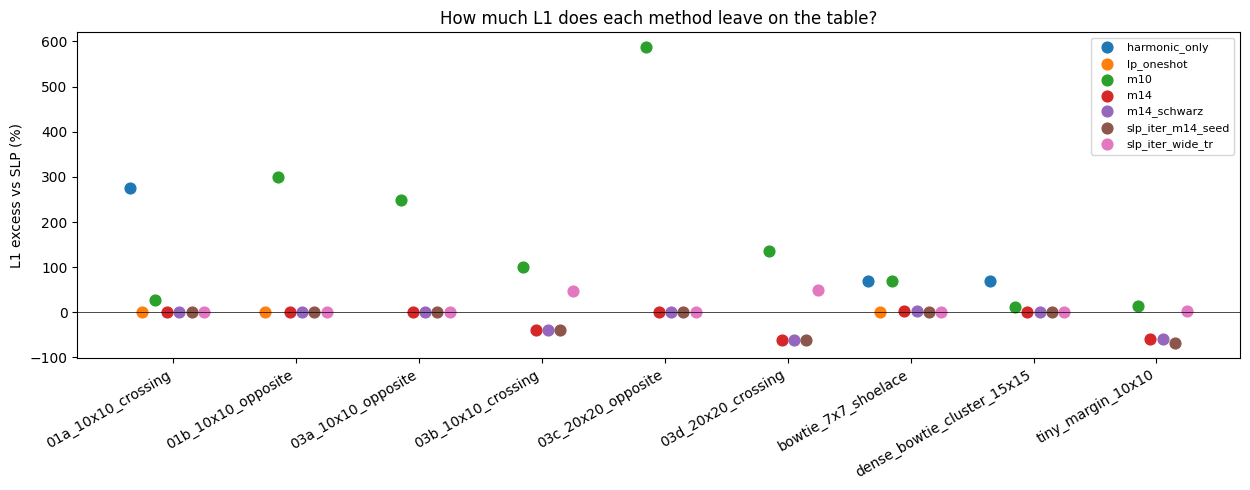

In [3]:
import matplotlib.pyplot as plt
import numpy as np

cases = gap.index.tolist()
methods = [m for m in gap.columns if m != 'slp_iter']
if cases and methods:
    fig, ax = plt.subplots(figsize=(max(8, 1.4 * len(cases)), 5))
    for i, m in enumerate(methods):
        y = gap[m].values
        x = np.arange(len(cases)) + 0.1 * (i - len(methods) / 2)
        ax.scatter(x, y, s=60, label=m)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xticks(np.arange(len(cases)))
    ax.set_xticklabels(cases, rotation=30, ha='right')
    ax.set_ylabel('L1 excess vs SLP (%)')
    ax.set_title('How much L1 does each method leave on the table?')
    ax.legend(loc='upper right', fontsize=8)
    fig.tight_layout()
    save_path = _HERE / 'l1_gap_vs_slp.png' if _HERE.name == 'analysis' else 'l1_gap_vs_slp.png'
    fig.savefig(save_path, dpi=150)
    plt.show()
else:
    print('No feasible cross-method rows to plot.')


In [4]:
# Convergence check: slp_iter.L1_dev vs lp_oneshot.L1_dev per case.
ones = df_feas[df_feas['method'] == 'lp_oneshot'][['case_id', 'L1_dev']].rename(
    columns={'L1_dev': 'L1_oneshot'}
)
slps = df_feas[df_feas['method'] == 'slp_iter'][['case_id', 'L1_dev']].rename(
    columns={'L1_dev': 'L1_slp'}
)
osvs = ones.merge(slps, on='case_id')
osvs['slp_minus_oneshot'] = osvs['L1_slp'] - osvs['L1_oneshot']
osvs.sort_values('slp_minus_oneshot')


,case_id,L1_oneshot,L1_slp,slp_minus_oneshot
1,01b_10x10_opposite,3.536215,3.536199,-1.613101e-05
0,01a_10x10_crossing,6.640329,6.640326,-2.885480e-06
2,bowtie_7x7_shoelace,1.420000,1.420000,4.440892e-16


## Conclusions

* If `slp_iter` has `feasible=True` on every case AND the gap-table
  shows non-negative entries everywhere: the no-compromise goal is met.
* If `slp_iter` fails feasibility on any case: trigger spec fallback
  row 1 (replace harmonic seed with m10 seed) for that case.
* If `slp_iter.L1_dev > cluster_pipeline.L1_dev` on >50% of B0039
  cases: trigger spec fallback row 5 (cluster_lp: solve LP per fold
  cluster instead of whole-slice).
* If `lp_oneshot` / `slp_iter` runs do not complete on the full
  B0039 slice within a wall budget: trigger spec fallback row 5
  (cluster_lp) for scale.
